# **--> Boosting Techniques Assignment <--**

**# Q&A**

    Q1. What is Boosting in Machine Learning? Explain how it improves weak learners
      = Boosting is an ensemble learning technique in machine learning where several weak learners are trained sequentially so that each new model focuses more on the mistakes made by the previous models. It combines the outputs of these weak learners to create a strong learner with better accuracy and performance. The main idea is to reduce bias and improve prediction power by giving more importance to difficult samples. In methods like AdaBoost and Gradient Boosting, misclassified or high-error instances are learned more carefully in later stages. Thus, boosting improves weak learners by turning them into a powerful final model through step-by-step learning and weighted combination.
    
    
    Q2. What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained
       = AdaBoost and Gradient Boosting differ mainly in their training approach where AdaBoost trains models sequentially by adjusting weights of misclassified samples so that each new weak learner focuses more on previously misclassified data, while Gradient Boosting trains models sequentially by minimizing a loss function using gradient descent where each new model learns to correct the residual errors of the previous model. In AdaBoost, sample weights are explicitly updated and final predictions are based on weighted voting, whereas in Gradient Boosting, models are added to reduce overall prediction error by fitting to gradients of the loss function. Thus, AdaBoost focuses on misclassification handling while Gradient Boosting focuses on error minimization through optimization.



    Q. How does regularization help in XGBoost?
       =Regularization in XGBoost helps control model complexity and prevents overfitting by penalizing very large or overly complex trees. It adds both L1 and L2 regularization to the objective function, which makes the model prefer simpler and more generalizable patterns instead of fitting noise in the training data. This improves the model’s ability to perform well on unseen data and makes it more stable and accurate. In XGBoost, regularization also helps prune unnecessary branches and reduce the effect of weak or irrelevant splits. Thus, regularization is an important reason why XGBoost gives strong performance with better generalization.




    Q. Why is CatBoost considered efficient for handling categorical data?      
       =CatBoost is considered efficient for handling categorical data because it uses a unique technique called ordered target encoding which converts categorical variables into numerical values without causing data leakage. Unlike traditional methods that require manual encoding like one-hot encoding, CatBoost automatically processes categorical features internally, reducing preprocessing effort and computational cost. It also uses permutation-driven learning to maintain the correct order of data and avoid overfitting. This approach improves model accuracy and stability, especially when dealing with high-cardinality categorical features. Hence, CatBoost provides efficient and reliable handling of categorical data in machine learning models.




    Q. What are some real-world applications where boosting techniques are preferred over bagging methods?
       =Boosting techniques are preferred in real-world applications where high accuracy and handling complex patterns are more important than speed, such as fraud detection, credit scoring, medical diagnosis, and ranking systems in search engines. These methods perform well on structured data with subtle patterns because they focus on reducing bias and correcting errors iteratively. Boosting algorithms like AdaBoost, Gradient Boosting, and XGBoost are widely used in competitions and industry due to their superior predictive performance. They are especially useful in imbalanced datasets where difficult cases need more attention. Thus, boosting is preferred when the goal is to achieve maximum accuracy and capture complex relationships in data.







In [1]:
#Q6. Train an AdaBoost Classifier on the Breast Cancer dataset and print the model accuracy

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = AdaBoostClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.9736842105263158


In [2]:
#Q7. Train a Gradient Boosting Regressor on the California Housing dataset and evaluate performance using R-squared score

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

data = fetch_california_housing()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(r2_score(y_test, y_pred))

0.7756446042829697


In [6]:
#Q8. Train an XGBoost Classifier on the Breast Cancer dataset, tune learning rate using GridSearchCV, and print best parameters and accuracy

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

params = {"learning_rate":[0.01,0.1,0.2,0.3]}
grid = GridSearchCV(XGBClassifier(eval_metric="logloss"), params, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print(grid.best_params_)
print(accuracy_score(y_test, y_pred))

{'learning_rate': 0.2}
0.956140350877193


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


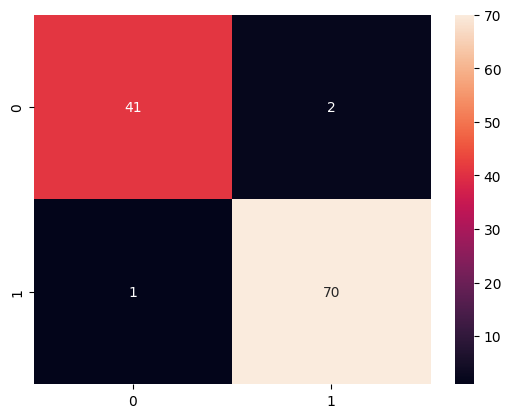

In [8]:
#Q9. Train a CatBoost Classifier and plot the confusion matrix using seaborn

!pip install catboost

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostClassifier(verbose=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

    Q10. You're working for a FinTech company trying to predict loan default using customer demographics and transaction behavior. Describe your step-by-step data science pipeline using boosting techniques
        = The pipeline begins with data understanding and preprocessing where missing values are handled using techniques like median imputation for numerical features and mode or a separate category for categorical features, ensuring minimal information loss. Categorical variables are encoded using target encoding or preferably handled directly using CatBoost which efficiently processes categorical data without extensive preprocessing. Feature scaling is generally not required for tree-based boosting models, but feature engineering such as creating ratios or behavioral indicators can improve model performance. For model selection, AdaBoost can be used as a simple baseline, XGBoost is chosen for its high performance and regularization capabilities, while CatBoost is ideal when the dataset contains many categorical features and missing values. Since the dataset is imbalanced, techniques like class weighting or resampling can be applied to improve minority class learning. Hyperparameter tuning is performed using GridSearchCV or RandomizedSearchCV focusing on key parameters such as learning rate, number of estimators, max_depth, and subsample ratio to balance bias and variance. Cross-validation is used to ensure model generalization and avoid overfitting. Evaluation metrics such as ROC-AUC are preferred as they measure classification performance across thresholds, while Precision and Recall are important to balance false positives and false negatives in loan default prediction. F1-score is used to get a balanced measure of both precision and recall, especially for imbalanced data. Finally, the trained model helps the business by accurately identifying high-risk customers, reducing loan defaults, improving credit decision-making, optimizing risk management strategies, and ultimately increasing profitability and financial stability.